# 6 — Switching to numpyro NUTS

Since v2.5, ``eddy`` ships a JAX-backed model and supports two MCMC
backends for :class:`~eddy.rotationmap.rotationmap.fit_map`:

- ``mcmc='emcee'`` — the historical default. Affine-invariant ensemble
  sampler with no gradient information; needs many walkers to explore
  high-dimensional posteriors.
- ``mcmc='numpyro'`` — opt-in NUTS sampler that uses the JAX gradient of
  the same likelihood. Far more sample-efficient at high dimensions
  (typically ``200`` post-warmup samples reach a posterior resolution
  comparable to emcee with ``32 walkers × 1000 samples``), at the cost
  of higher per-sample wall time.

Both backends agree to within sampling noise on the standard 9-parameter
HD163296 3D fit (see ``REFACTORING_PLAN.md §5.1b``); pick whichever
suits the problem.

This short tutorial demonstrates the numpyro path on the same data used
in `Tutorial 2 <tutorial_2.html>`_.


## Setup

The data files are the same as Tutorial 2 — download them if you
haven't already.


In [1]:
import os
if not os.path.exists('HD163296_CO_v0.fits'):
    !wget -O HD163296_CO_v0.fits -q https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/C2ZUNO/AWCSZR
if not os.path.exists('HD163296_CO_dv0.fits'):
    !wget -O HD163296_CO_dv0.fits -q https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/C2ZUNO/NGOW49


In [2]:
from eddy import rotationmap

cube = rotationmap(path='HD163296_CO_v0.fits',
                   uncertainty='HD163296_CO_dv0.fits',
                   FOV=8.0, downsample=4)


## Tightening unbounded priors

NUTS samples in an *unconstrained* parameter space and uses a bijective
transform to map back to the prior support. For ``Uniform(lo, hi)`` the
transform is well-conditioned only when both bounds are finite; an
improper prior such as ``r_taper ∈ (0, ∞)`` (the default) maps to an
unbounded ``log`` transform whose curvature is poor at large values, and
NUTS trees blow up to thousands of leapfrog steps per iteration.

emcee tolerates unbounded uniforms transparently because it only
inspects the bounds, but for the numpyro path it pays to tighten any
``inf`` upper or lower bound to a finite value larger than the
physically interesting range. For HD163296, ``r_taper`` larger than the
field of view is irrelevant, so a generous ceiling of 50″ works:


In [3]:
cube.set_prior('r_taper', [0.0, 50.0], 'flat')


## Setting up the fit

The free-parameter dictionary, fixed parameters, and ``p0`` are
identical to the 9-parameter 3D fit in Tutorial 2. Only the call to
``fit_map`` changes.


In [4]:
params = {}
params['x0'] = 0
params['y0'] = 1
params['PA'] = 2
params['mstar'] = 3
params['vlsr'] = 4
params['z0'] = 5
params['psi'] = 6
params['r_taper'] = 7
params['q_taper'] = 8

params['inc'] = 46.7
params['dist'] = 101.0
params['r_min'] = 2.0 * cube.bmaj

p0 = [0.0, 0.0, 312., 2.0, 5.7e3, 0.25, 1.0, 3.0, 2.0]


## Running the fit

The MCMC backend is selected with the ``mcmc=`` keyword. The legacy
walker/burnin/step kwargs map onto numpyro's ``num_chains`` /
``num_warmup`` / ``num_samples`` internally, so existing scripts can
switch backends by changing one keyword:

==================  =========================
``fit_map`` kwarg   numpyro equivalent
==================  =========================
``nwalkers``        ``num_chains``
``nburnin``         ``num_warmup``
``nsteps``          ``num_samples``
==================  =========================

NUTS additionally accepts a few sampler-specific kwargs through
``mcmc_kwargs``:

- ``seed`` — PRNG key seed (default ``0``).
- ``progress`` — show a progress bar (default ``True``).
- ``max_tree_depth`` — cap the doubling tree depth. Default is 10
  (≤1024 leapfrog steps per NUTS iteration); for typical
  ``rotationmap`` fits, ``8`` (≤256 steps) roughly halves wall time
  with no measurable loss in posterior resolution.
- ``chain_method`` — passed through to
  :class:`numpyro.infer.MCMC`. Default ``'sequential'``.

Single-chain NUTS with 500 warmup + 500 samples is a reasonable starting
budget for a 9-parameter fit. The full run takes a few minutes on a
modern CPU and is dominated by JAX compilation and the warmup
adaptation.


W0513 08:43:36.249279 15637893 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Assuming:
	p0 = [x0, y0, PA, mstar, vlsr, z0, psi, r_taper, q_taper].


Optimized starting positions:
	p0 = ['-1.39e-02', '-3.35e-02', '3.12e+02', '1.93e+00', '5.70e+03', '2.34e-01', '1.66e+00', '3.30e+00', '1.97e+00']


  0%|          | 0/1000 [00:00<?, ?it/s]

warmup:   0%|          | 0/1000 [00:10<?, ?it/s, 31 steps of size 1.11e-04. acc. prob=0.70]

...

sample: 100%|██████████| 1000/1000 [14:19<00:00,  1.16it/s, 63 steps of size 1.46e-02. acc. prob=0.92]

/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges
/Users/richardteague/miniconda3/lib/python3.13/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


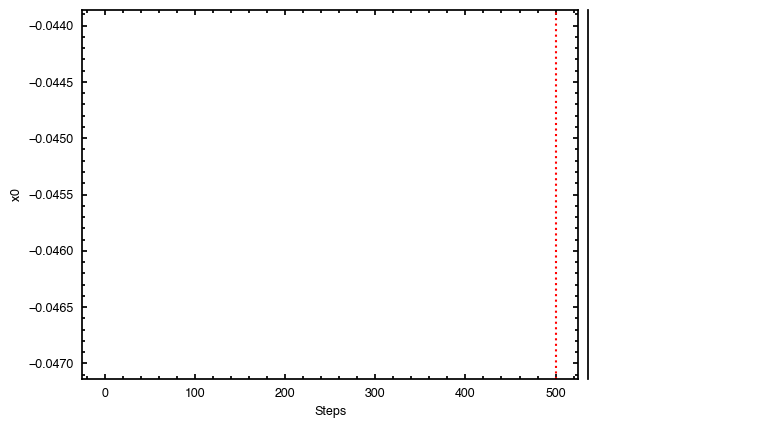

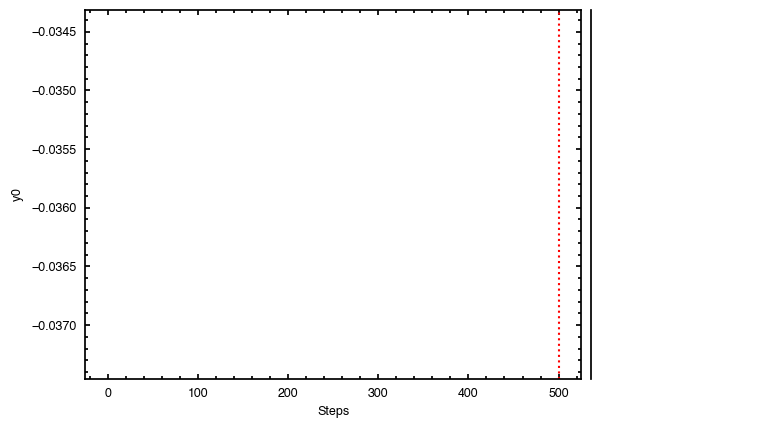

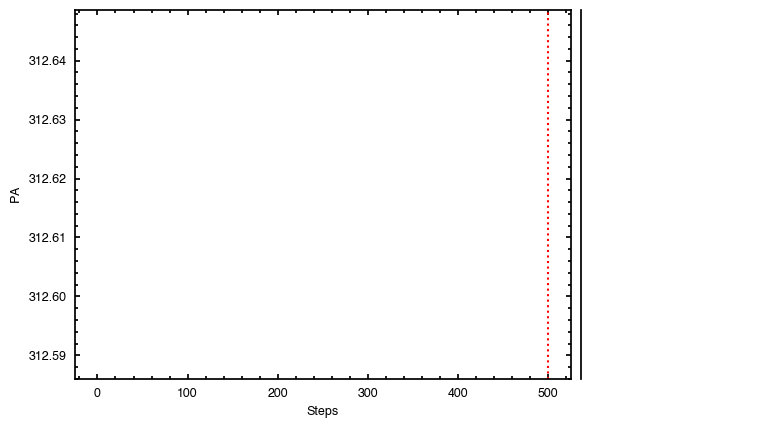

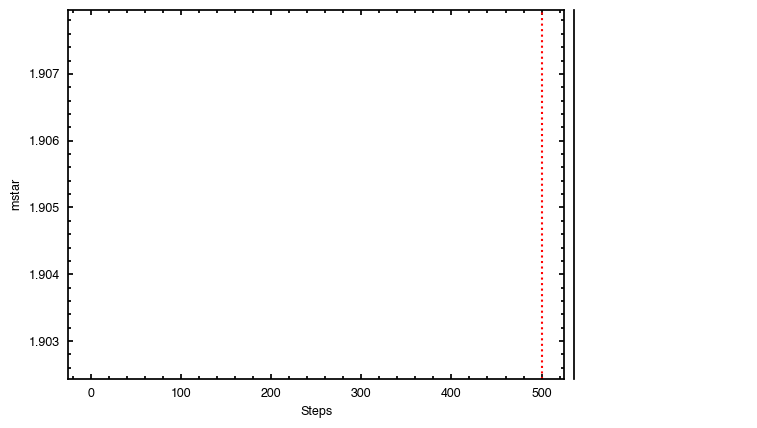

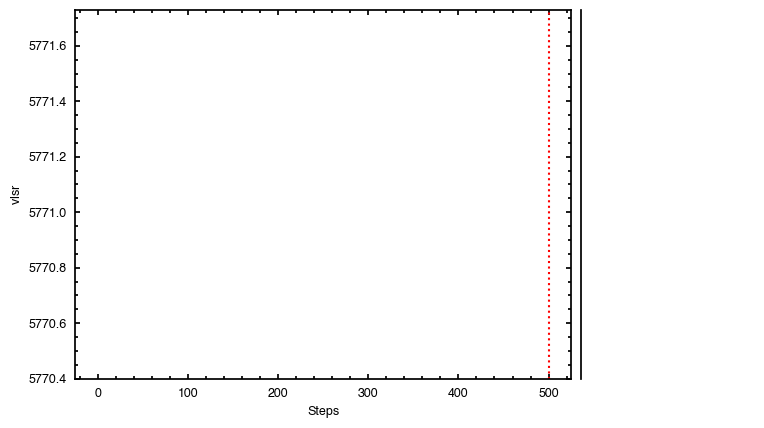

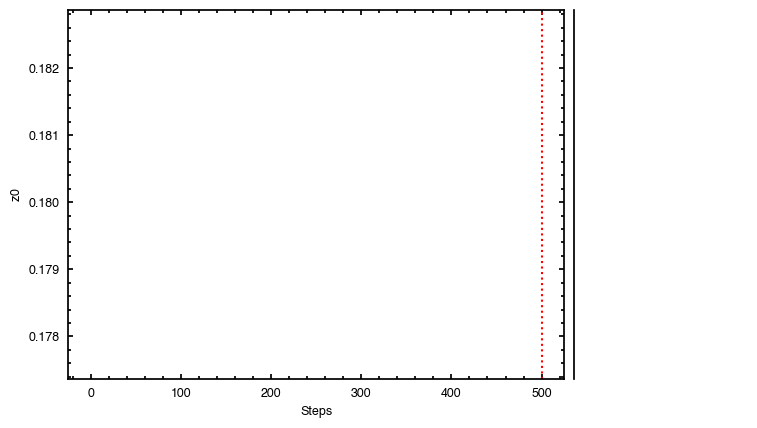

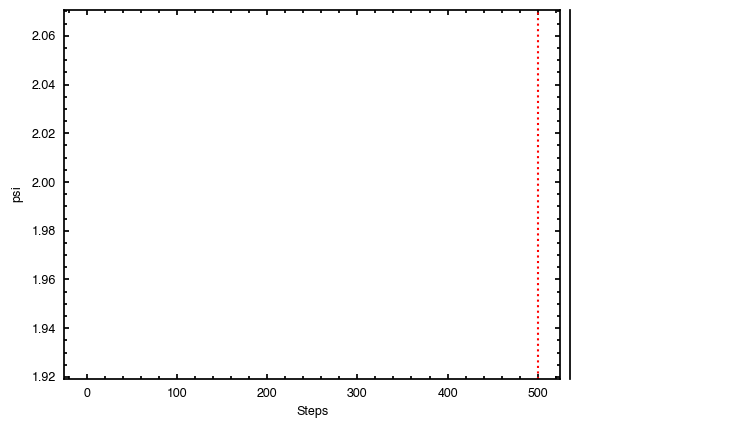

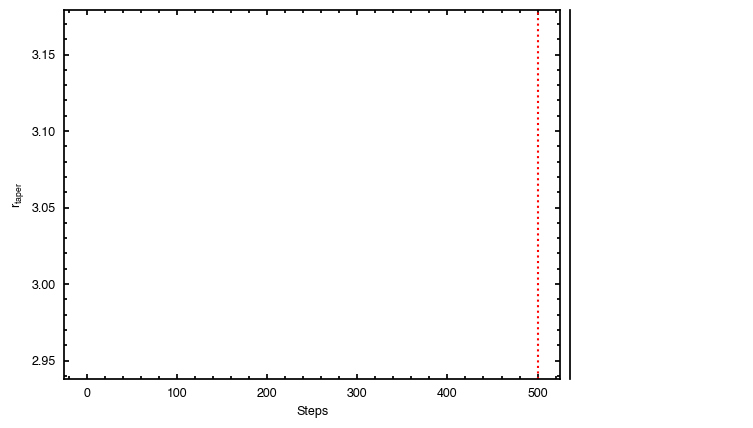

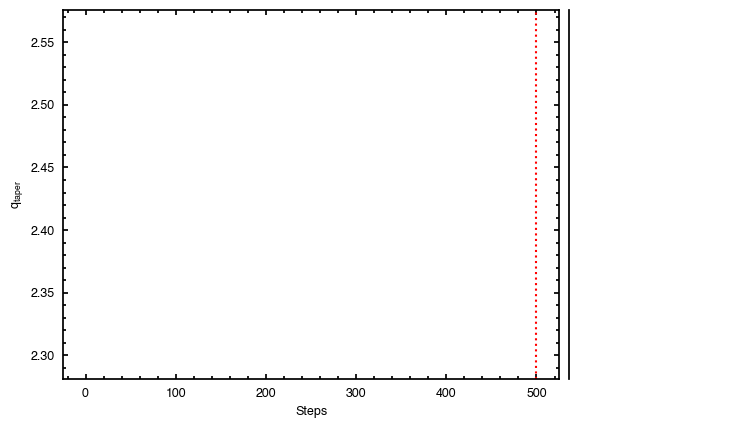

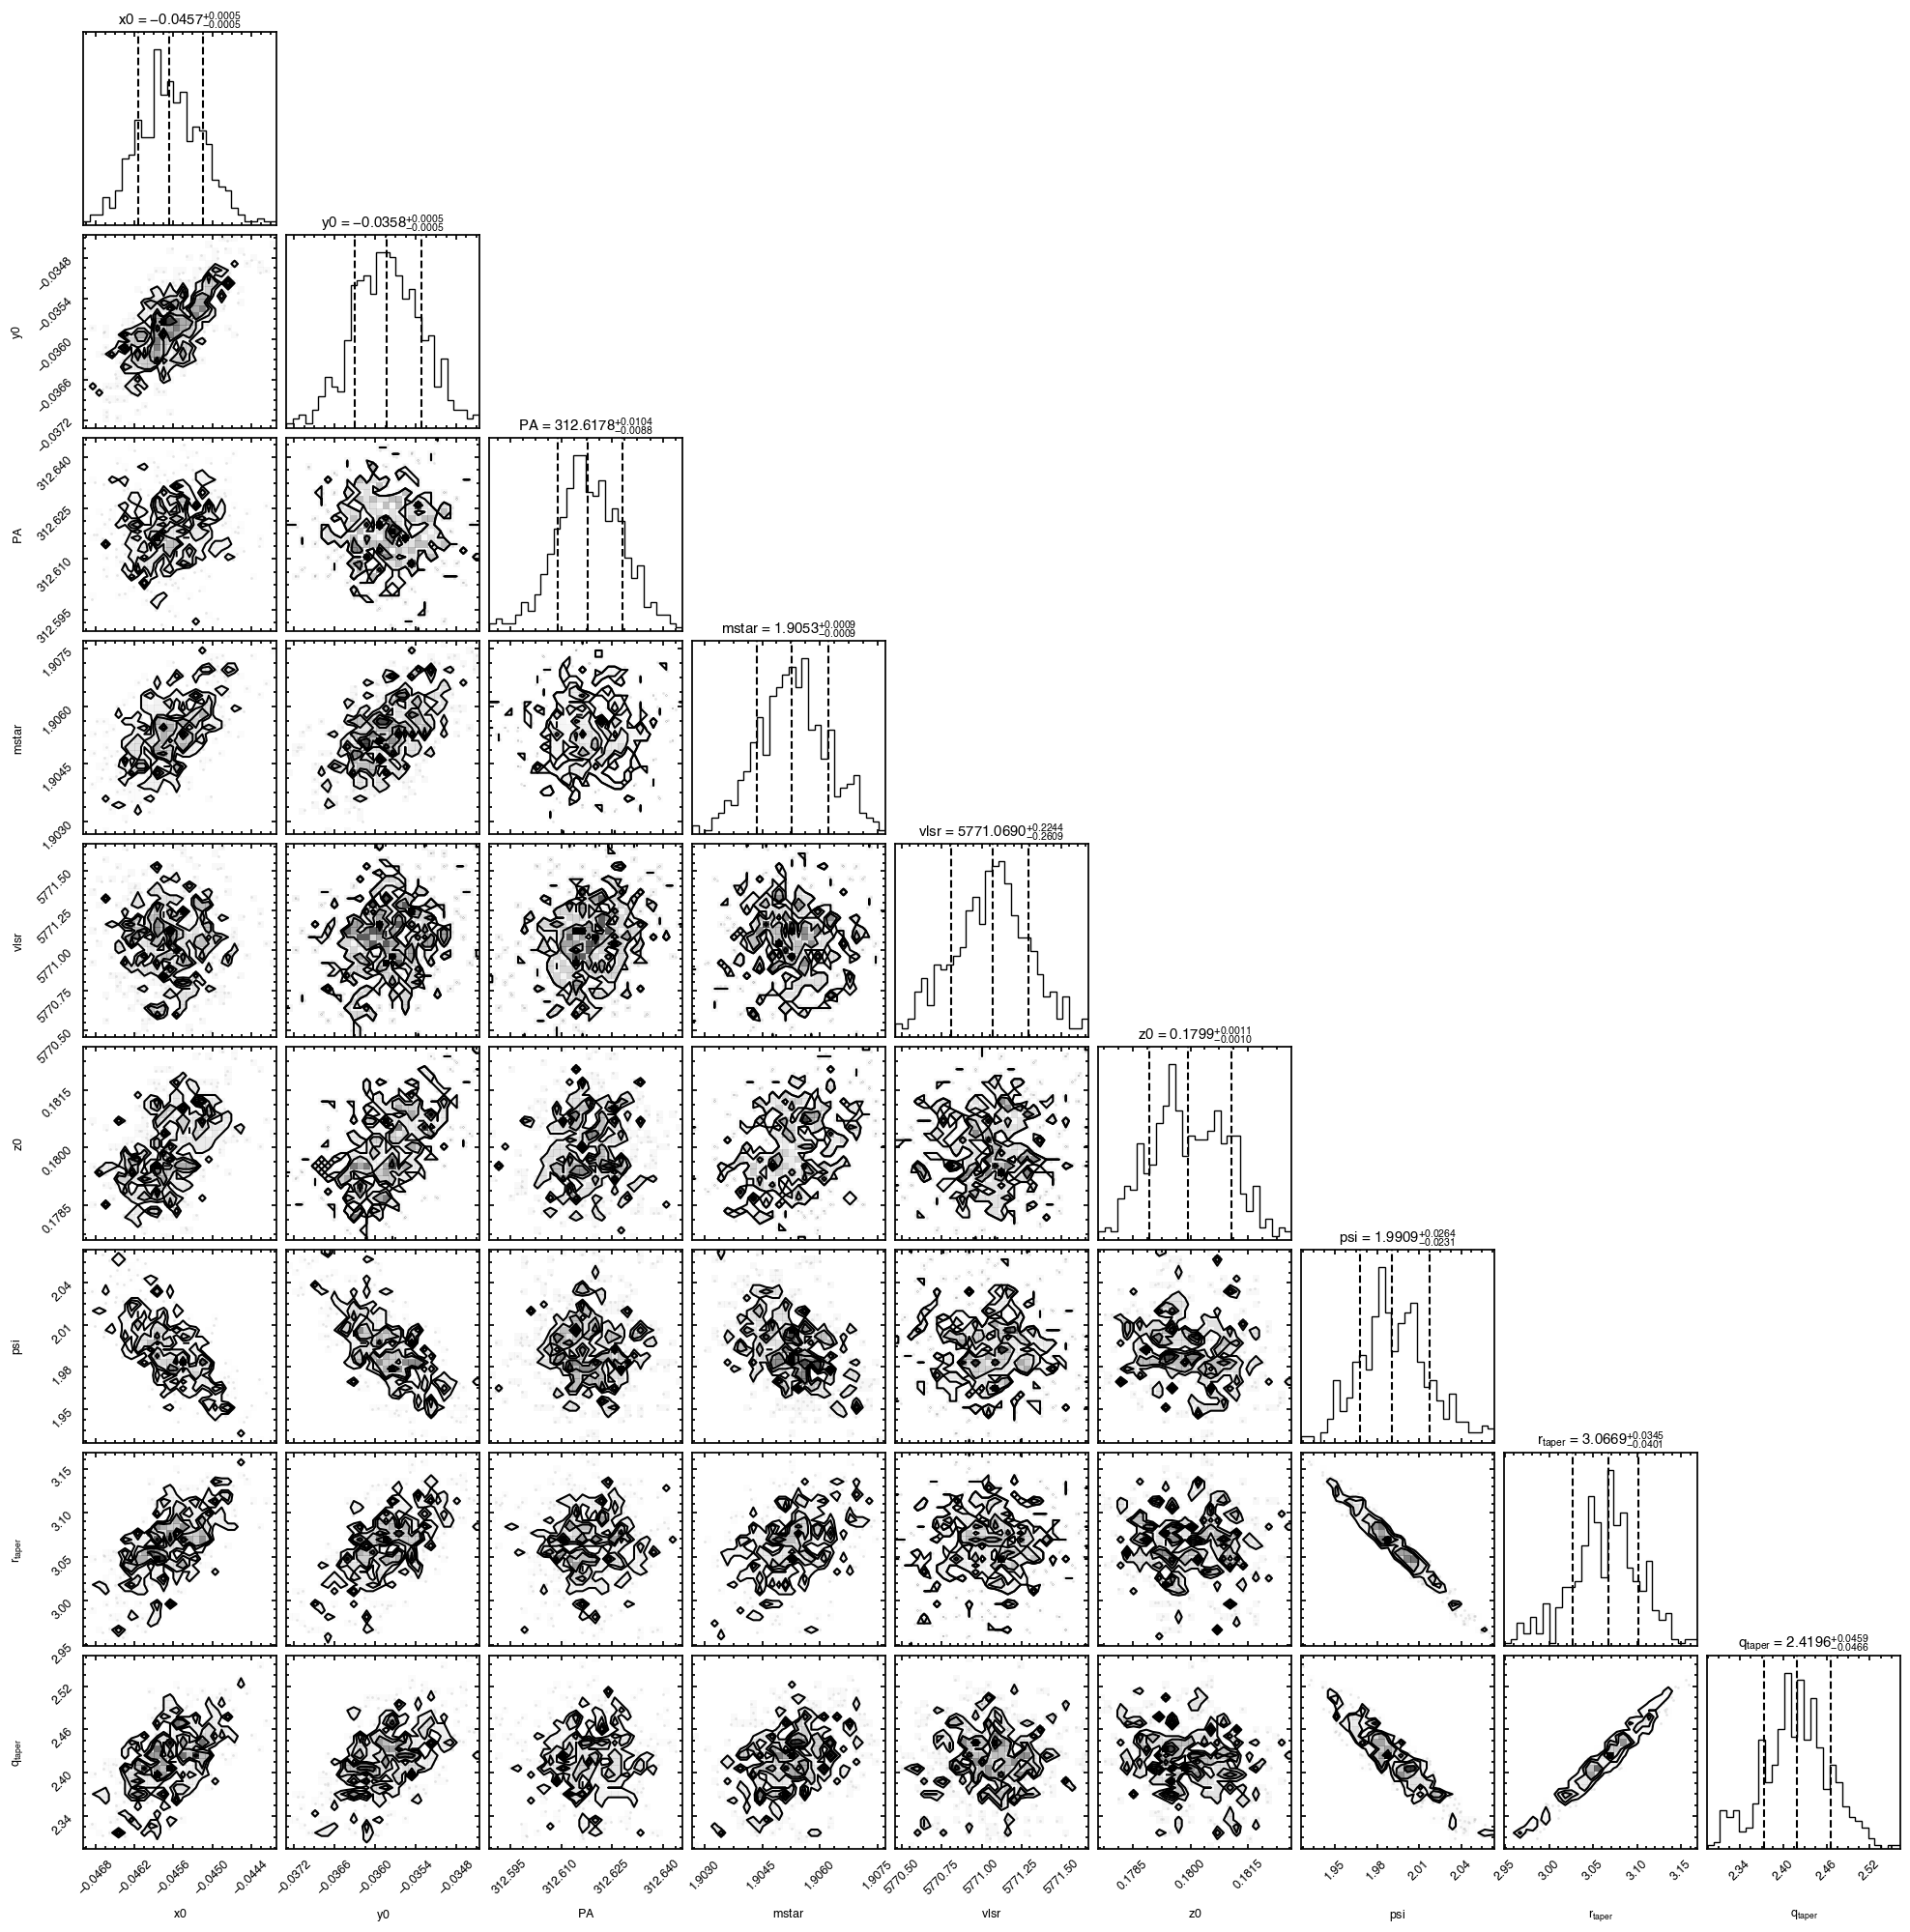

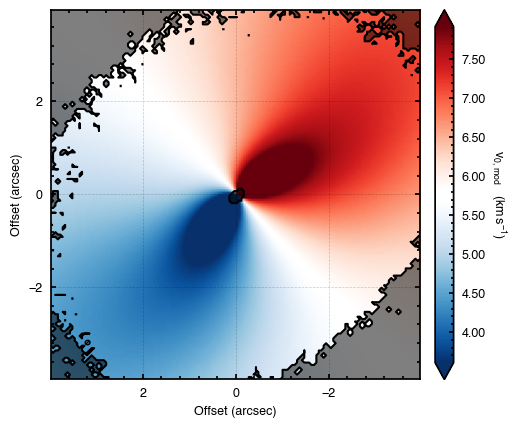

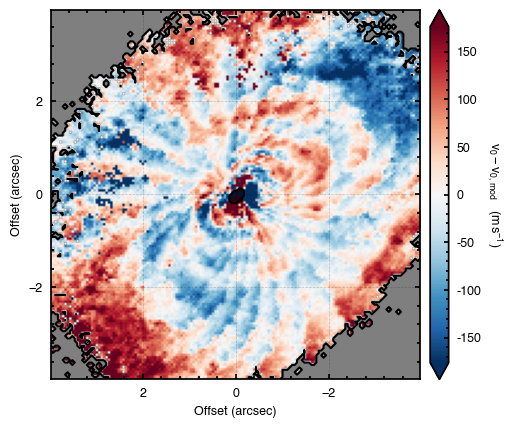

In [5]:
samples = cube.fit_map(
    p0=p0, params=params, optimize=True,
    nwalkers=1,    # numpyro: num_chains
    nburnin=500,   # numpyro: num_warmup
    nsteps=500,    # numpyro: num_samples
    mcmc='numpyro',
    mcmc_kwargs={
        'seed': 0,
        'progress': True,
        'max_tree_depth': 8,
    },
    plots=['walkers', 'corner', 'bestfit', 'residual'],
    returns=['samples', 'percentiles'],
)


## When to choose which backend

emcee remains the recommended default for routine fits — it's
embarrassingly parallel across walkers, has no JAX warm-up cost, and
each likelihood evaluation is cheap. Switch to numpyro when one of
these matches:

- The posterior is high-dimensional (≳ 8 free parameters) *and* you'd
  otherwise need a very long emcee chain to bring the autocorrelation
  time under control.
- You're running on a GPU. numpyro inherits JAX's device
  auto-detection, so a single ``mcmc='numpyro'`` call uses the GPU
  without further configuration.
- You want the same analytic gradient that ``optimize=True`` already
  uses internally to also drive the MCMC step.

For small (≲ 5-parameter) 2D fits, emcee is generally faster in wall
time. The two backends are statistically equivalent on the validation
fit recorded in ``REFACTORING_PLAN.md §5.1b``: medians match within
0.2 σ on every parameter and posterior widths agree within 9 %.
